<a href="https://colab.research.google.com/github/Omar-Zantot/Hybrid-Soft-Computing/blob/main/HSC_DP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introduction ✒

---
## 1.1 Problem Statement
Early diagnosis is critical for many diseases, especially **diabetes**, which is increasing in prevalence globally. According to the **World Health Organization (WHO)**, by 2030, **1 in 10 adults** will be affected by diabetes. Early detection allows for **better management** and **prevention** of complications such as kidney failure, heart disease, and blindness. Traditional methods like **clinical assessments**, **laboratory tests**, and **imaging** can sometimes fail to detect diseases early enough, particularly when symptoms are **subclinical** or **ambiguous**. This leads to the necessity for **advanced computational models** that can **predict diseases early** using complex, high-dimensional data.

## 1.2 Objective of the Study
We compare single models (ANN, SVM, Decision Tree) with hybrid soft computing models (e.g., Fuzzy+ANN) for diabetes prediction, focusing on accuracy and robustness with real-world, noisy healthcare data.

## 1.3 Focus of the Comparative Study
Five algorithms (single and hybrid) are evaluated on the same dataset using metrics like accuracy, precision, recall, F1-score, and AUC-ROC.

# 2. Importing Libraries

In [30]:
import joblib
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import skfuzzy as fuzz
from skfuzzy import control as ctrl

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# 3. Dataset Preparation
### 3.1 Dataset Description
We use the Pima Indians Diabetes Dataset, which contains 8 features and a binary outcome (1: diabetes, 0: no diabetes).

| No | Column Name               | Meaning                         |
|----|--------------------------|---------------------------------|
| 1  | Pregnancies              | Number of pregnancies           |
| 2  | Glucose                  | Glucose level in blood          |
| 3  | BloodPressure            | Blood pressure measurement      |
| 4  | SkinThickness            | Thickness of the skin           |
| 5  | Insulin                  | Insulin level in blood          |
| 6  | BMI                      | Body mass index                 |
| 7  | DiabetesPedigreeFunction | Genetic diabetes risk           |
| 8  | Age                      | Age                             |
| 9  | Outcome                  | 1: Diabetes, 0: No diabetes     |


In [2]:
# Load dataset
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 4. Exploratory Data Analysis (EDA)

In [4]:
# Basic info and summary
print(df.info())
print(df.describe())
print(df.Outcome.value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

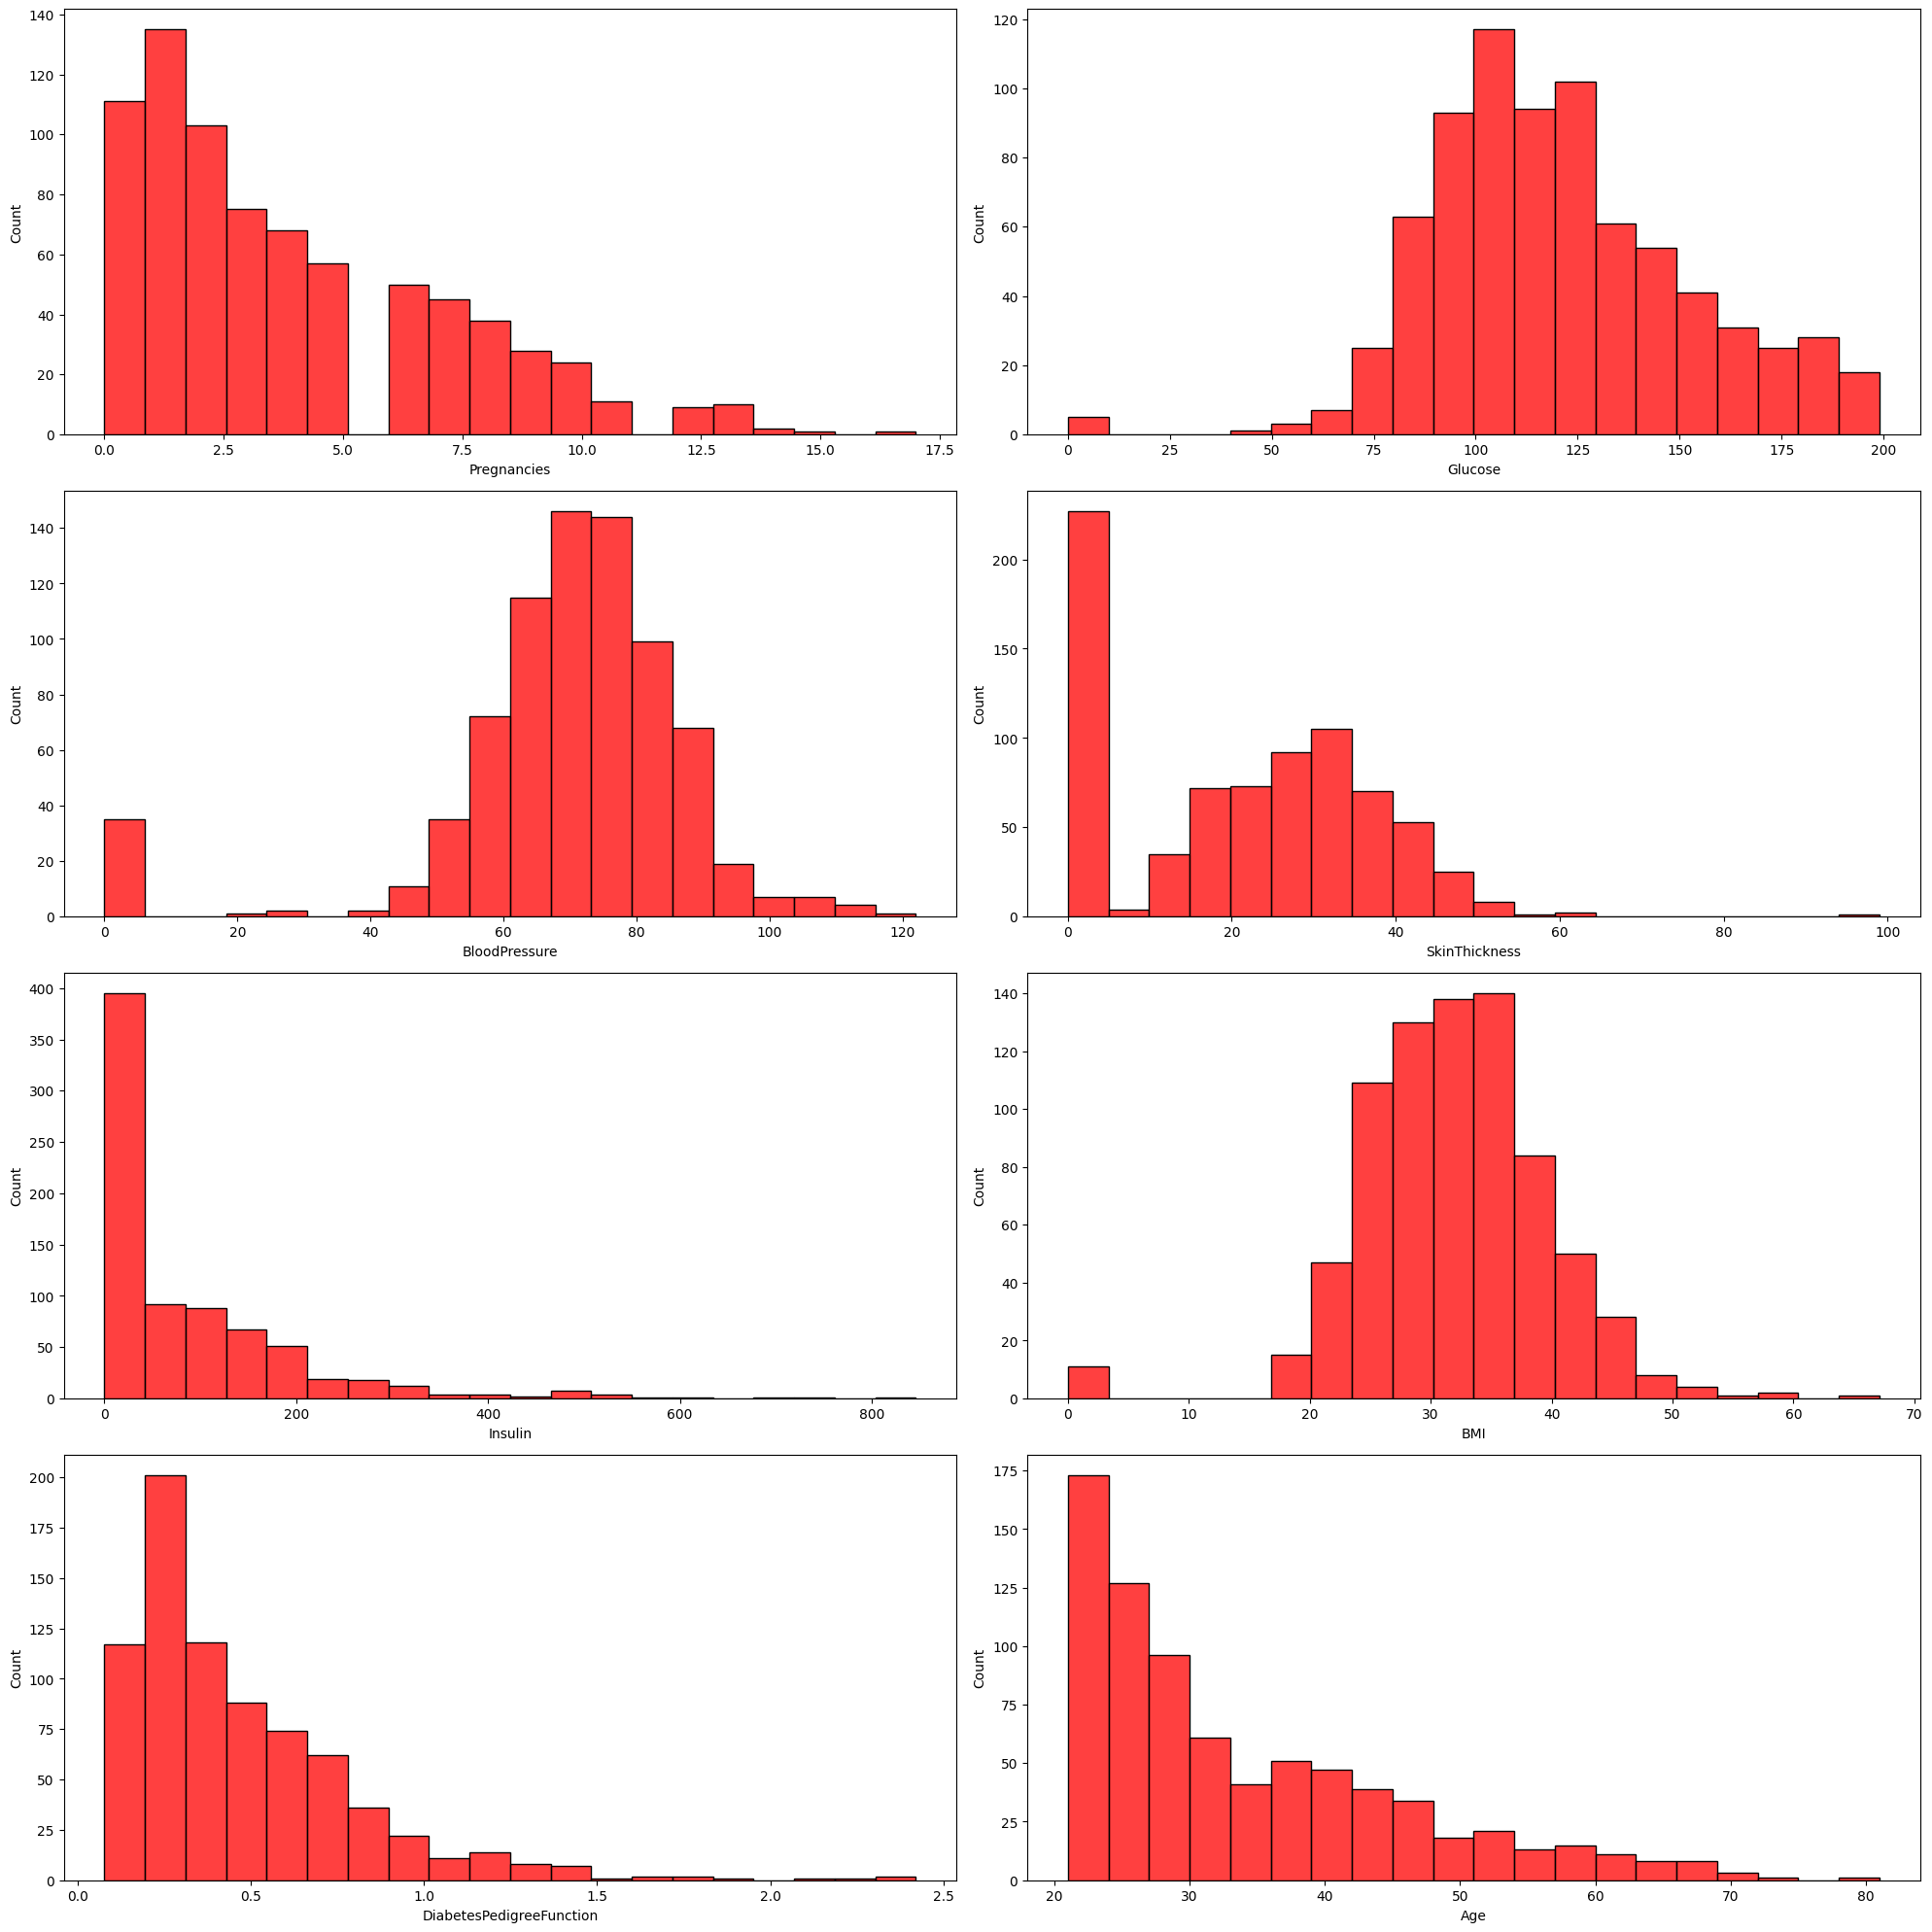

In [5]:
# Visualizations: Distribution of features
fig, ax = plt.subplots(4, 2, figsize=(20, 20))
for i, col in enumerate(df.columns[:-1]):
    sns.histplot(df[col], bins=20, ax=ax[i//2, i%2], color="red")
plt.tight_layout()
plt.show()

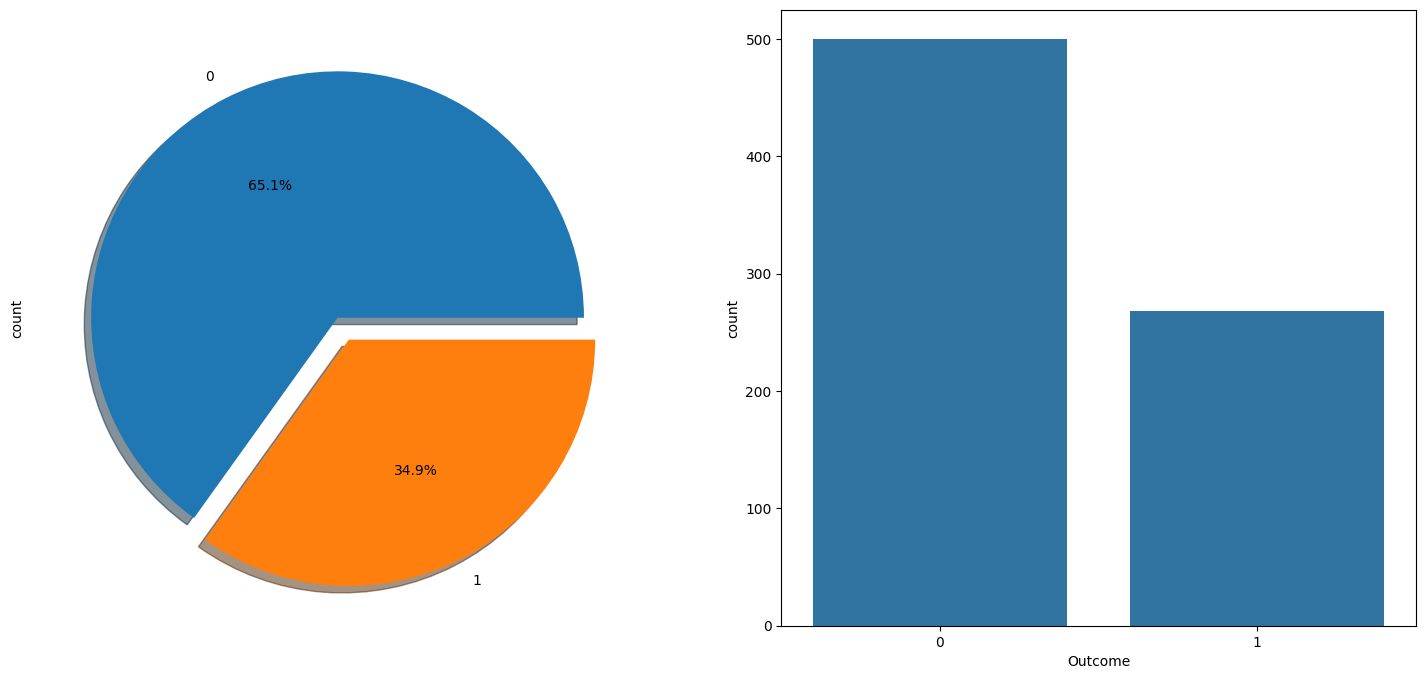

In [6]:
# Outcome distribution
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df['Outcome'].value_counts().plot.pie(explode=[0, 0.1], autopct="%1.1f%%", ax=ax[0], shadow=True)
sns.countplot(x='Outcome', data=df, ax=ax[1])
plt.show()

In [7]:
# Check for missing and zero values
print(df.isnull().sum())
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    print(f"{col}: {len(df[df[col] == 0])}")

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


# 5. Data Preprocessing

---



In [8]:
# Replace invalid zeros with NaN
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Impute missing values with median by Outcome
def median_target(var):
    temp = df[df[var].notnull()]
    return temp.groupby('Outcome')[var].median()

for col in zero_cols:
    medians = median_target(col)
    df.loc[(df['Outcome'] == 0) & (df[col].isnull()), col] = medians[0]
    df.loc[(df['Outcome'] == 1) & (df[col].isnull()), col] = medians[1]

# Outlier handling for Insulin (IQR method)
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
df.loc[df['Insulin'] > upper, 'Insulin'] = upper

In [9]:
# Feature engineering: BMI and Glucose categories
df['NewBMI'] = pd.cut(df['BMI'], bins=[0, 18.5, 24.9, 29.9, 34.9, 39.9, np.inf],
                      labels=["Underweight", "Normal", "Overweight", "Obesity 1", "Obesity 2", "Obesity 3"])
df['NewInsulinScore'] = df['Insulin'].apply(lambda x: "Normal" if 16 <= x <= 166 else "Abnormal")
df['NewGlucose'] = pd.cut(df['Glucose'], bins=[0, 70, 99, 126, np.inf],
                          labels=["Low", "Normal", "Overweight", "High"])

# One-hot encoding for new categorical features
df = pd.get_dummies(df, columns=['NewBMI', 'NewInsulinScore', 'NewGlucose'], drop_first=True)

In [57]:
# Prepare features and target
y = df['Outcome']
X = df.drop(['Outcome'], axis=1)

# Robust scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)


In [58]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 6. Evaluation Function

---



In [12]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, is_ann=False):
    results = []
    for X, y_true, label in [(X_train, y_train, "Training"), (X_test, y_test, "Validation")]:
        if is_ann:
            y_pred = (model.predict(X) > 0.5).astype("int32").flatten()
            y_proba = model.predict(X).flatten()
        else:
            y_pred = model.predict(X)
            y_proba = model.predict_proba(X)[:, 1]
        report = classification_report(y_true, y_pred, output_dict=True, digits=4)
        print(f"\n📊 Classification Report - {model_name} ({label})")
        print(classification_report(y_true, y_pred, digits=4))
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
        plt.title(f'Confusion Matrix - {model_name} ({label})')
        plt.show()
        results.append({
            'Model': model_name,
            'Dataset': label,
            'Accuracy': report['accuracy'],
            'Precision': report['1']['precision'],
            'Recall': report['1']['recall'],
            'F1-Score': report['1']['f1-score'],
            'AUC-ROC': roc_auc_score(y_true, y_proba)
        })
    return pd.DataFrame(results)

# 7. Single Model Training and Evaluation

---




📊 Classification Report - Decision Tree (Training)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       393
           1     1.0000    1.0000    1.0000       221

    accuracy                         1.0000       614
   macro avg     1.0000    1.0000    1.0000       614
weighted avg     1.0000    1.0000    1.0000       614



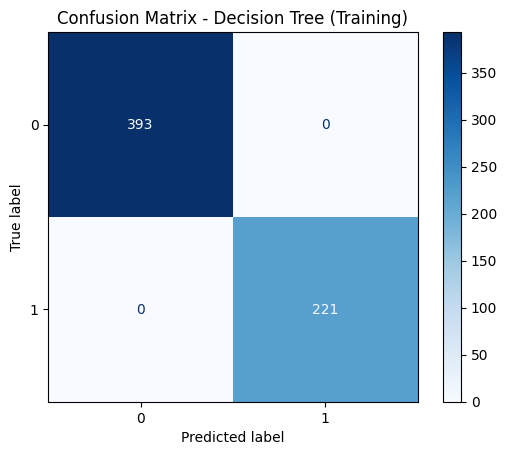


📊 Classification Report - Decision Tree (Validation)
              precision    recall  f1-score   support

           0     0.9029    0.8692    0.8857       107
           1     0.7255    0.7872    0.7551        47

    accuracy                         0.8442       154
   macro avg     0.8142    0.8282    0.8204       154
weighted avg     0.8488    0.8442    0.8459       154



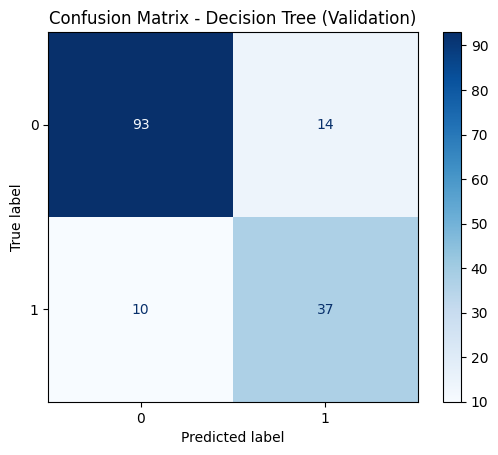

In [13]:
# Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
dt_results = evaluate_model(dtree, "Decision Tree", X_train, X_test, y_train, y_test)


📊 Classification Report - SVM (Training)
              precision    recall  f1-score   support

           0     0.9150    0.9313    0.9231       393
           1     0.8738    0.8462    0.8598       221

    accuracy                         0.9007       614
   macro avg     0.8944    0.8887    0.8914       614
weighted avg     0.9002    0.9007    0.9003       614



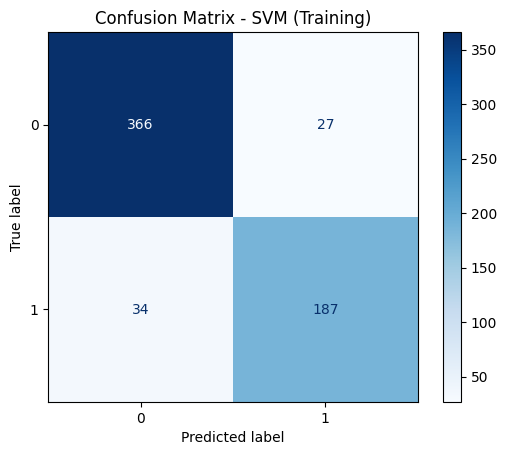


📊 Classification Report - SVM (Validation)
              precision    recall  f1-score   support

           0     0.9515    0.9159    0.9333       107
           1     0.8235    0.8936    0.8571        47

    accuracy                         0.9091       154
   macro avg     0.8875    0.9048    0.8952       154
weighted avg     0.9124    0.9091    0.9101       154



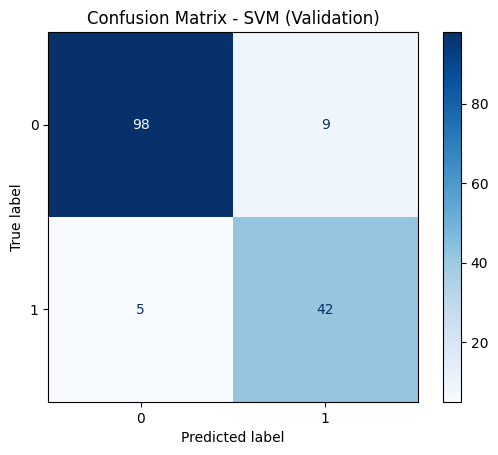

In [14]:
# SVM
svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
svm_results = evaluate_model(svm, "SVM", X_train, X_test, y_train, y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📊 Classification Report - ANN (Training)
              precision    recall  f1-score   support

           0     0.8492    0.8601    0.8546       393
           1     0.7454    0.7285    0.7368       221

    accuracy                         0.8127       614
   macro avg     0.7973    0.7943    0.7957       614
weighted avg     0.8119    0.8127    0.8122       614



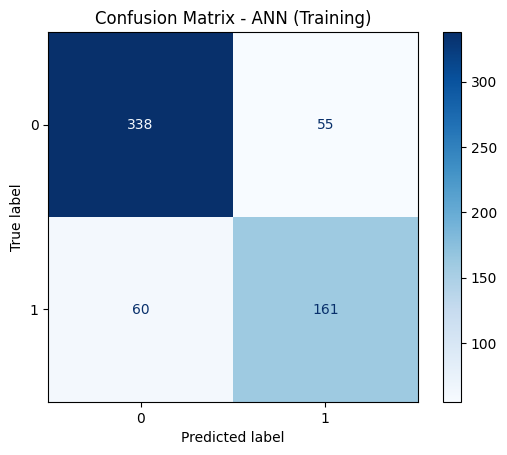

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 Classification Report - ANN (Validation)
              precision    recall  f1-score   support

           0     0.9485    0.8598    0.9020       107
           1     0.7368    0.8936    0.8077        47

    accuracy                         0.8701       154
   macro avg     0.8426    0.8767    0.8548       154
weighted avg     0.8839    0.8701    0.8732       154



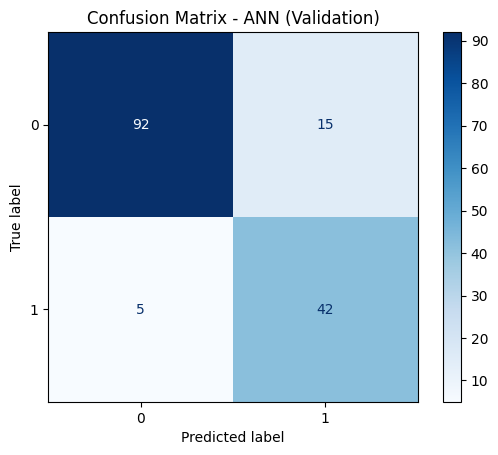

In [15]:
# ANN
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ann.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)
ann_results = evaluate_model(ann, "ANN", X_train, X_test, y_train, y_test, is_ann=True)

           Model     Dataset  Accuracy  Precision    Recall  F1-Score  \
0  Decision Tree    Training  1.000000   1.000000  1.000000  1.000000   
1  Decision Tree  Validation  0.844156   0.725490  0.787234  0.755102   
2            SVM    Training  0.900651   0.873832  0.846154  0.859770   
3            SVM  Validation  0.909091   0.823529  0.893617  0.857143   
4            ANN    Training  0.812704   0.745370  0.728507  0.736842   
5            ANN  Validation  0.870130   0.736842  0.893617  0.807692   

    AUC-ROC  
0  1.000000  
1  0.828196  
2  0.948039  
3  0.946311  
4  0.887695  
5  0.924239  


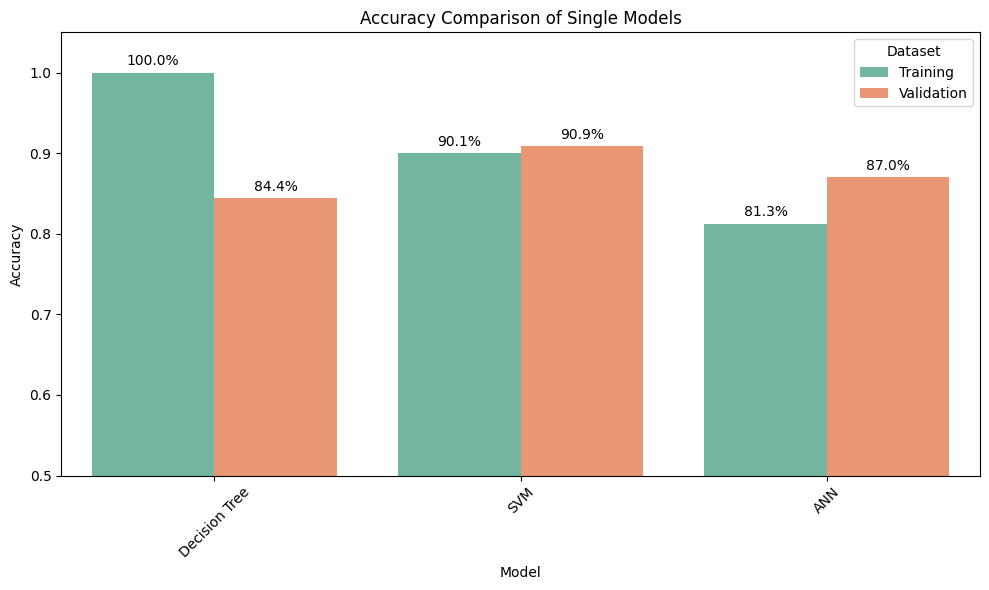

In [16]:
# Combine and display results
single_model_results = pd.concat([dt_results, svm_results, ann_results], ignore_index=True)
print(single_model_results)

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=single_model_results, x='Model', y='Accuracy', hue='Dataset', palette='Set2')
plt.ylim(0.5, 1.05)
plt.title('Accuracy Comparison of Single Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, labels=[f'{h.get_height()*100:.1f}%' for h in container])
plt.tight_layout()
plt.show()

# 7 | Hybrid Models

## 7.1 | Fuzzy Logic + ANN (Neuro-Fuzzy System)

### Overview:
A hybrid Fuzzy + ANN model, often called an Adaptive Neuro-Fuzzy Inference System (ANFIS), combines the interpretability of fuzzy logic with the learning power of neural networks. This approach is well-suited for medical data where uncertainty, vagueness, and nonlinear relationships are common.

#### Step 1: Fuzzy Feature Engineering
Fuzzy logic is used to transform key continuous features (such as Glucose, BMI, Insulin, Age) into fuzzy linguistic variables (e.g., "Low", "Normal", "High"). This step mimics expert reasoning and enhances the model's ability to handle ambiguous or borderline cases.

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📊 Classification Report - Fuzzy + ANN (Training)
              precision    recall  f1-score   support

           0     0.9268    0.9476    0.9371       401
           1     0.8971    0.8592    0.8777       213

    accuracy                         0.9169       614
   macro avg     0.9119    0.9034    0.9074       614
weighted avg     0.9165    0.9169    0.9165       614



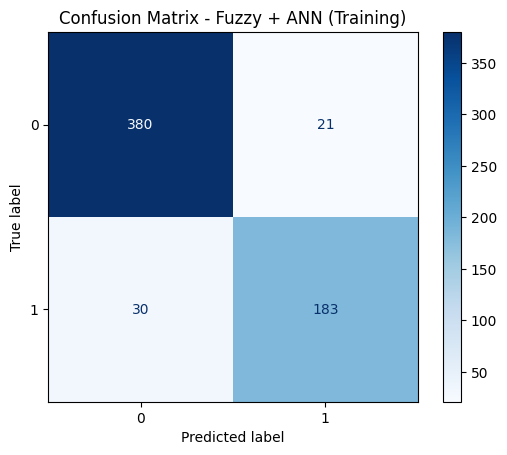

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 Classification Report - Fuzzy + ANN (Validation)
              precision    recall  f1-score   support

           0     0.8700    0.8788    0.8744        99
           1     0.7778    0.7636    0.7706        55

    accuracy                         0.8377       154
   macro avg     0.8239    0.8212    0.8225       154
weighted avg     0.8371    0.8377    0.8373       154



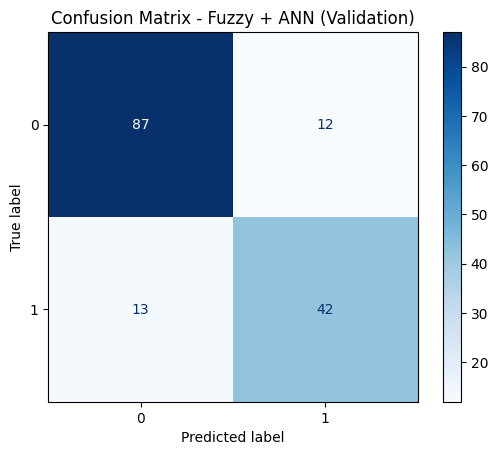

In [31]:
glucose = ctrl.Antecedent(np.arange(0, 201, 1), 'glucose')
bmi = ctrl.Antecedent(np.arange(0, 67, 1), 'bmi')
insulin = ctrl.Antecedent(np.arange(0, 846, 1), 'insulin')
risk = ctrl.Consequent(np.arange(0, 11, 1), 'risk')

glucose.automf(3)
bmi.automf(3)
insulin.automf(3)
risk.automf(3)

rule1 = ctrl.Rule(glucose['poor'] | bmi['poor'], risk['poor'])
rule2 = ctrl.Rule(glucose['average'] & insulin['average'], risk['average'])
rule3 = ctrl.Rule(glucose['good'] & bmi['good'], risk['good'])

risk_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

fuzzy_scores = []
for i in range(len(df)):
    risk_sim.input['glucose'] = df.loc[i, 'Glucose']
    risk_sim.input['bmi'] = df.loc[i, 'BMI']
    risk_sim.input['insulin'] = df.loc[i, 'Insulin']
    try:
        risk_sim.compute()
        fuzzy_scores.append(risk_sim.output['risk'])
    except:
        fuzzy_scores.append(np.nan)

df['FuzzyRisk'] = fuzzy_scores
df['FuzzyRisk'].fillna(df['FuzzyRisk'].mean(), inplace=True)

X_fuzzy = df.drop(columns=['Outcome'])
y_fuzzy = df['Outcome']
X_train_fz, X_test_fz, y_train_fz, y_test_fz = train_test_split(X_fuzzy, y_fuzzy, test_size=0.2, random_state=42)

scaler_fz = StandardScaler()
X_train_fz_scaled = scaler_fz.fit_transform(X_train_fz)
X_test_fz_scaled = scaler_fz.transform(X_test_fz)

ann_fuzzy = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_fz_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
ann_fuzzy.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_fuzzy.fit(X_train_fz_scaled, y_train_fz, validation_split=0.2, epochs=100, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=10)], verbose=0)

fuzzy_ann_results = evaluate_model(ann_fuzzy, "Fuzzy + ANN", X_train_fz_scaled, X_test_fz_scaled, y_train_fz, y_test_fz, is_ann=True)

In [17]:
# !pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.7 MB/s eta 0:00:00


In [40]:
import skfuzzy as fuzz

# Clinical ranges for glucose (mg/dL)
glucose_range = np.arange(0, 200, 1)
glucose_low = fuzz.trimf(glucose_range, [0, 70, 100])       # Hypoglycemia <70
glucose_normal = fuzz.trimf(glucose_range, [70, 100, 125])  # Normal 70-99
glucose_high = fuzz.trimf(glucose_range, [100, 125, 200])   # Diabetic ≥126

# WHO BMI categories (kg/m²)
bmi_range = np.arange(0, 60, 0.1)
bmi_under = fuzz.trimf(bmi_range, [0, 16, 18.5])
bmi_normal = fuzz.trimf(bmi_range, [16, 18.5, 25])
bmi_over = fuzz.trimf(bmi_range, [18.5, 25, 30])
bmi_obese1 = fuzz.trimf(bmi_range, [25, 30, 35])
bmi_obese2 = fuzz.trimf(bmi_range, [30, 35, 40])
bmi_obese3 = fuzz.trimf(bmi_range, [35, 40, 60])

# Insulin normal range (pmol/L)
insulin_range = np.arange(0, 850, 1)
insulin_low = fuzz.trimf(insulin_range, [0, 16, 166])      # Normal fasting: 16-166
insulin_normal = fuzz.trimf(insulin_range, [16, 166, 300])
insulin_high = fuzz.trimf(insulin_range, [166, 300, 846])

# DiabetesPedigreeFunction thresholds[11]
dpf_range = np.arange(0, 2.5, 0.01)
dpf_low = fuzz.trimf(dpf_range, [0, 0.2, 0.6])
dpf_medium = fuzz.trimf(dpf_range, [0.2, 0.6, 1.0])
dpf_high = fuzz.trimf(dpf_range, [0.6, 1.0, 2.5])

# Age risk groups[8]
age_range = np.arange(21, 90, 1)
age_young = fuzz.trimf(age_range, [21, 30, 45])    # Lower risk
age_middle = fuzz.trimf(age_range, [30, 45, 60])   # Moderate risk
age_old = fuzz.trimf(age_range, [45, 60, 90])      # Higher risk


In [43]:
fuzzy_features = pd.DataFrame()

# Glucose memberships
fuzzy_features['Glucose_Low'] = df['Glucose'].apply(lambda x: fuzz.interp_membership(glucose_range, glucose_low, x))
fuzzy_features['Glucose_Normal'] = df['Glucose'].apply(lambda x: fuzz.interp_membership(glucose_range, glucose_normal, x))
fuzzy_features['Glucose_High'] = df['Glucose'].apply(lambda x: fuzz.interp_membership(glucose_range, glucose_high, x))

# BMI memberships
fuzzy_features['BMI_Under'] = df['BMI'].apply(lambda x: fuzz.interp_membership(bmi_range, bmi_under, x))
fuzzy_features['BMI_Normal'] = df['BMI'].apply(lambda x: fuzz.interp_membership(bmi_range, bmi_normal, x))
fuzzy_features['BMI_Over'] = df['BMI'].apply(lambda x: fuzz.interp_membership(bmi_range, bmi_over, x))
fuzzy_features['BMI_Obese1'] = df['BMI'].apply(lambda x: fuzz.interp_membership(bmi_range, bmi_obese1, x))
fuzzy_features['BMI_Obese2'] = df['BMI'].apply(lambda x: fuzz.interp_membership(bmi_range, bmi_obese2, x))
fuzzy_features['BMI_Obese3'] = df['BMI'].apply(lambda x: fuzz.interp_membership(bmi_range, bmi_obese3, x))

# Insulin memberships
fuzzy_features['Insulin_Low'] = df['Insulin'].apply(lambda x: fuzz.interp_membership(insulin_range, insulin_low, x))
fuzzy_features['Insulin_Normal'] = df['Insulin'].apply(lambda x: fuzz.interp_membership(insulin_range, insulin_normal, x))
fuzzy_features['Insulin_High'] = df['Insulin'].apply(lambda x: fuzz.interp_membership(insulin_range, insulin_high, x))

# DPF memberships
fuzzy_features['DPF_Low'] = df['DiabetesPedigreeFunction'].apply(lambda x: fuzz.interp_membership(dpf_range, dpf_low, x))
fuzzy_features['DPF_Medium'] = df['DiabetesPedigreeFunction'].apply(lambda x: fuzz.interp_membership(dpf_range, dpf_medium, x))
fuzzy_features['DPF_High'] = df['DiabetesPedigreeFunction'].apply(lambda x: fuzz.interp_membership(dpf_range, dpf_high, x))

# Age memberships
fuzzy_features['Age_Young'] = df['Age'].apply(lambda x: fuzz.interp_membership(age_range, age_young, x))
fuzzy_features['Age_Middle'] = df['Age'].apply(lambda x: fuzz.interp_membership(age_range, age_middle, x))
fuzzy_features['Age_Old'] = df['Age'].apply(lambda x: fuzz.interp_membership(age_range, age_old, x))




In [45]:
# Scale original features
scaler = RobustScaler()
original_scaled = pd.DataFrame(scaler.fit_transform(df[['Pregnancies', 'Glucose', 'BloodPressure',
                                                        'SkinThickness', 'Insulin', 'BMI',
                                                        'DiabetesPedigreeFunction', 'Age']]),
                              columns=['Pregnancies', 'Glucose', 'BloodPressure',
                                       'SkinThickness', 'Insulin', 'BMI',
                                       'DiabetesPedigreeFunction', 'Age'])

# Hybrid dataset
X_hybrid = pd.concat([original_scaled, fuzzy_features], axis=1)
y_hybrid = df['Outcome']

# Split hybrid dataset
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(
    X_hybrid,
    y_hybrid,
    test_size=0.2,
    random_state=42
)



In [46]:
hybrid_ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_hybrid.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

hybrid_ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = hybrid_ann.fit(
    X_train_hybrid, y_train_hybrid,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📊 Classification Report - Fuzzy+ANN (Training)
              precision    recall  f1-score   support

           0     0.9474    0.9426    0.9450       401
           1     0.8930    0.9014    0.8972       213

    accuracy                         0.9283       614
   macro avg     0.9202    0.9220    0.9211       614
weighted avg     0.9285    0.9283    0.9284       614



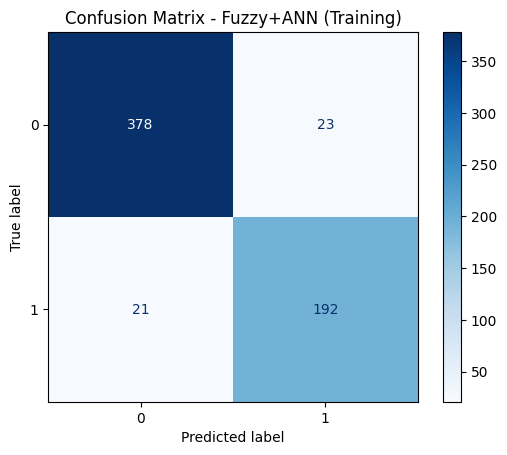

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 Classification Report - Fuzzy+ANN (Validation)
              precision    recall  f1-score   support

           0     0.9032    0.8485    0.8750        99
           1     0.7541    0.8364    0.7931        55

    accuracy                         0.8442       154
   macro avg     0.8287    0.8424    0.8341       154
weighted avg     0.8500    0.8442    0.8458       154



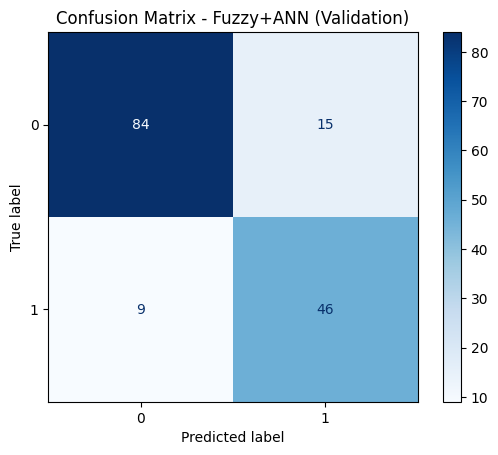

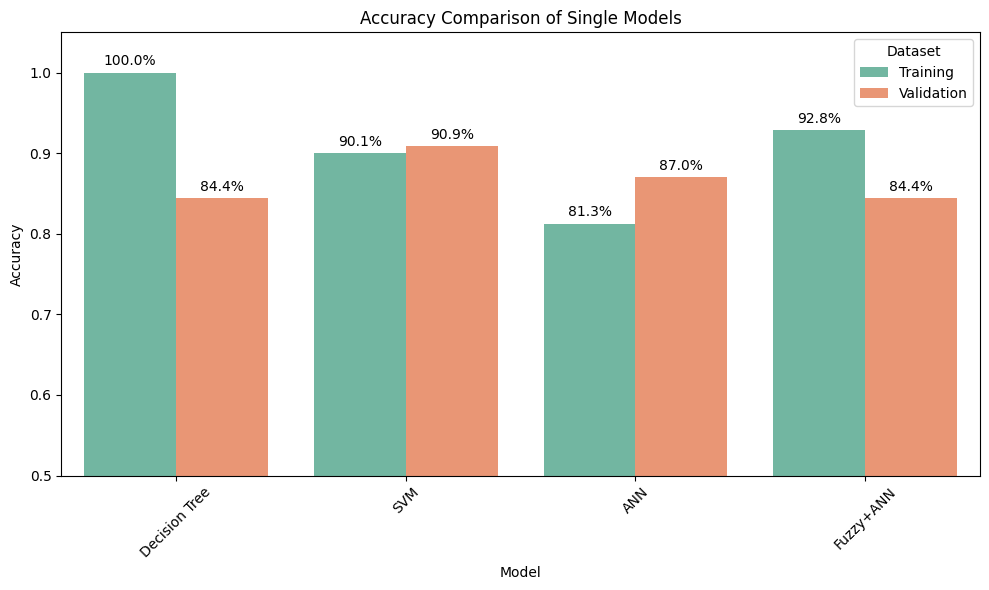

In [48]:
hybrid_results = evaluate_model(hybrid_ann, "Fuzzy+ANN",
                               X_train_hybrid, X_test_hybrid,
                               y_train_hybrid, y_test_hybrid,
                               is_ann=True)

# Combine all results
final_results = pd.concat([single_model_results, hybrid_results], ignore_index=True)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=final_results, x='Model', y='Accuracy', hue='Dataset', palette='Set2')
plt.ylim(0.5, 1.05)
plt.title('Accuracy Comparison of Single Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, labels=[f'{h.get_height()*100:.1f}%' for h in container])
plt.tight_layout()
plt.show()


In [67]:
import joblib
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor

import skfuzzy as fuzz
from skfuzzy import control as ctrl

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

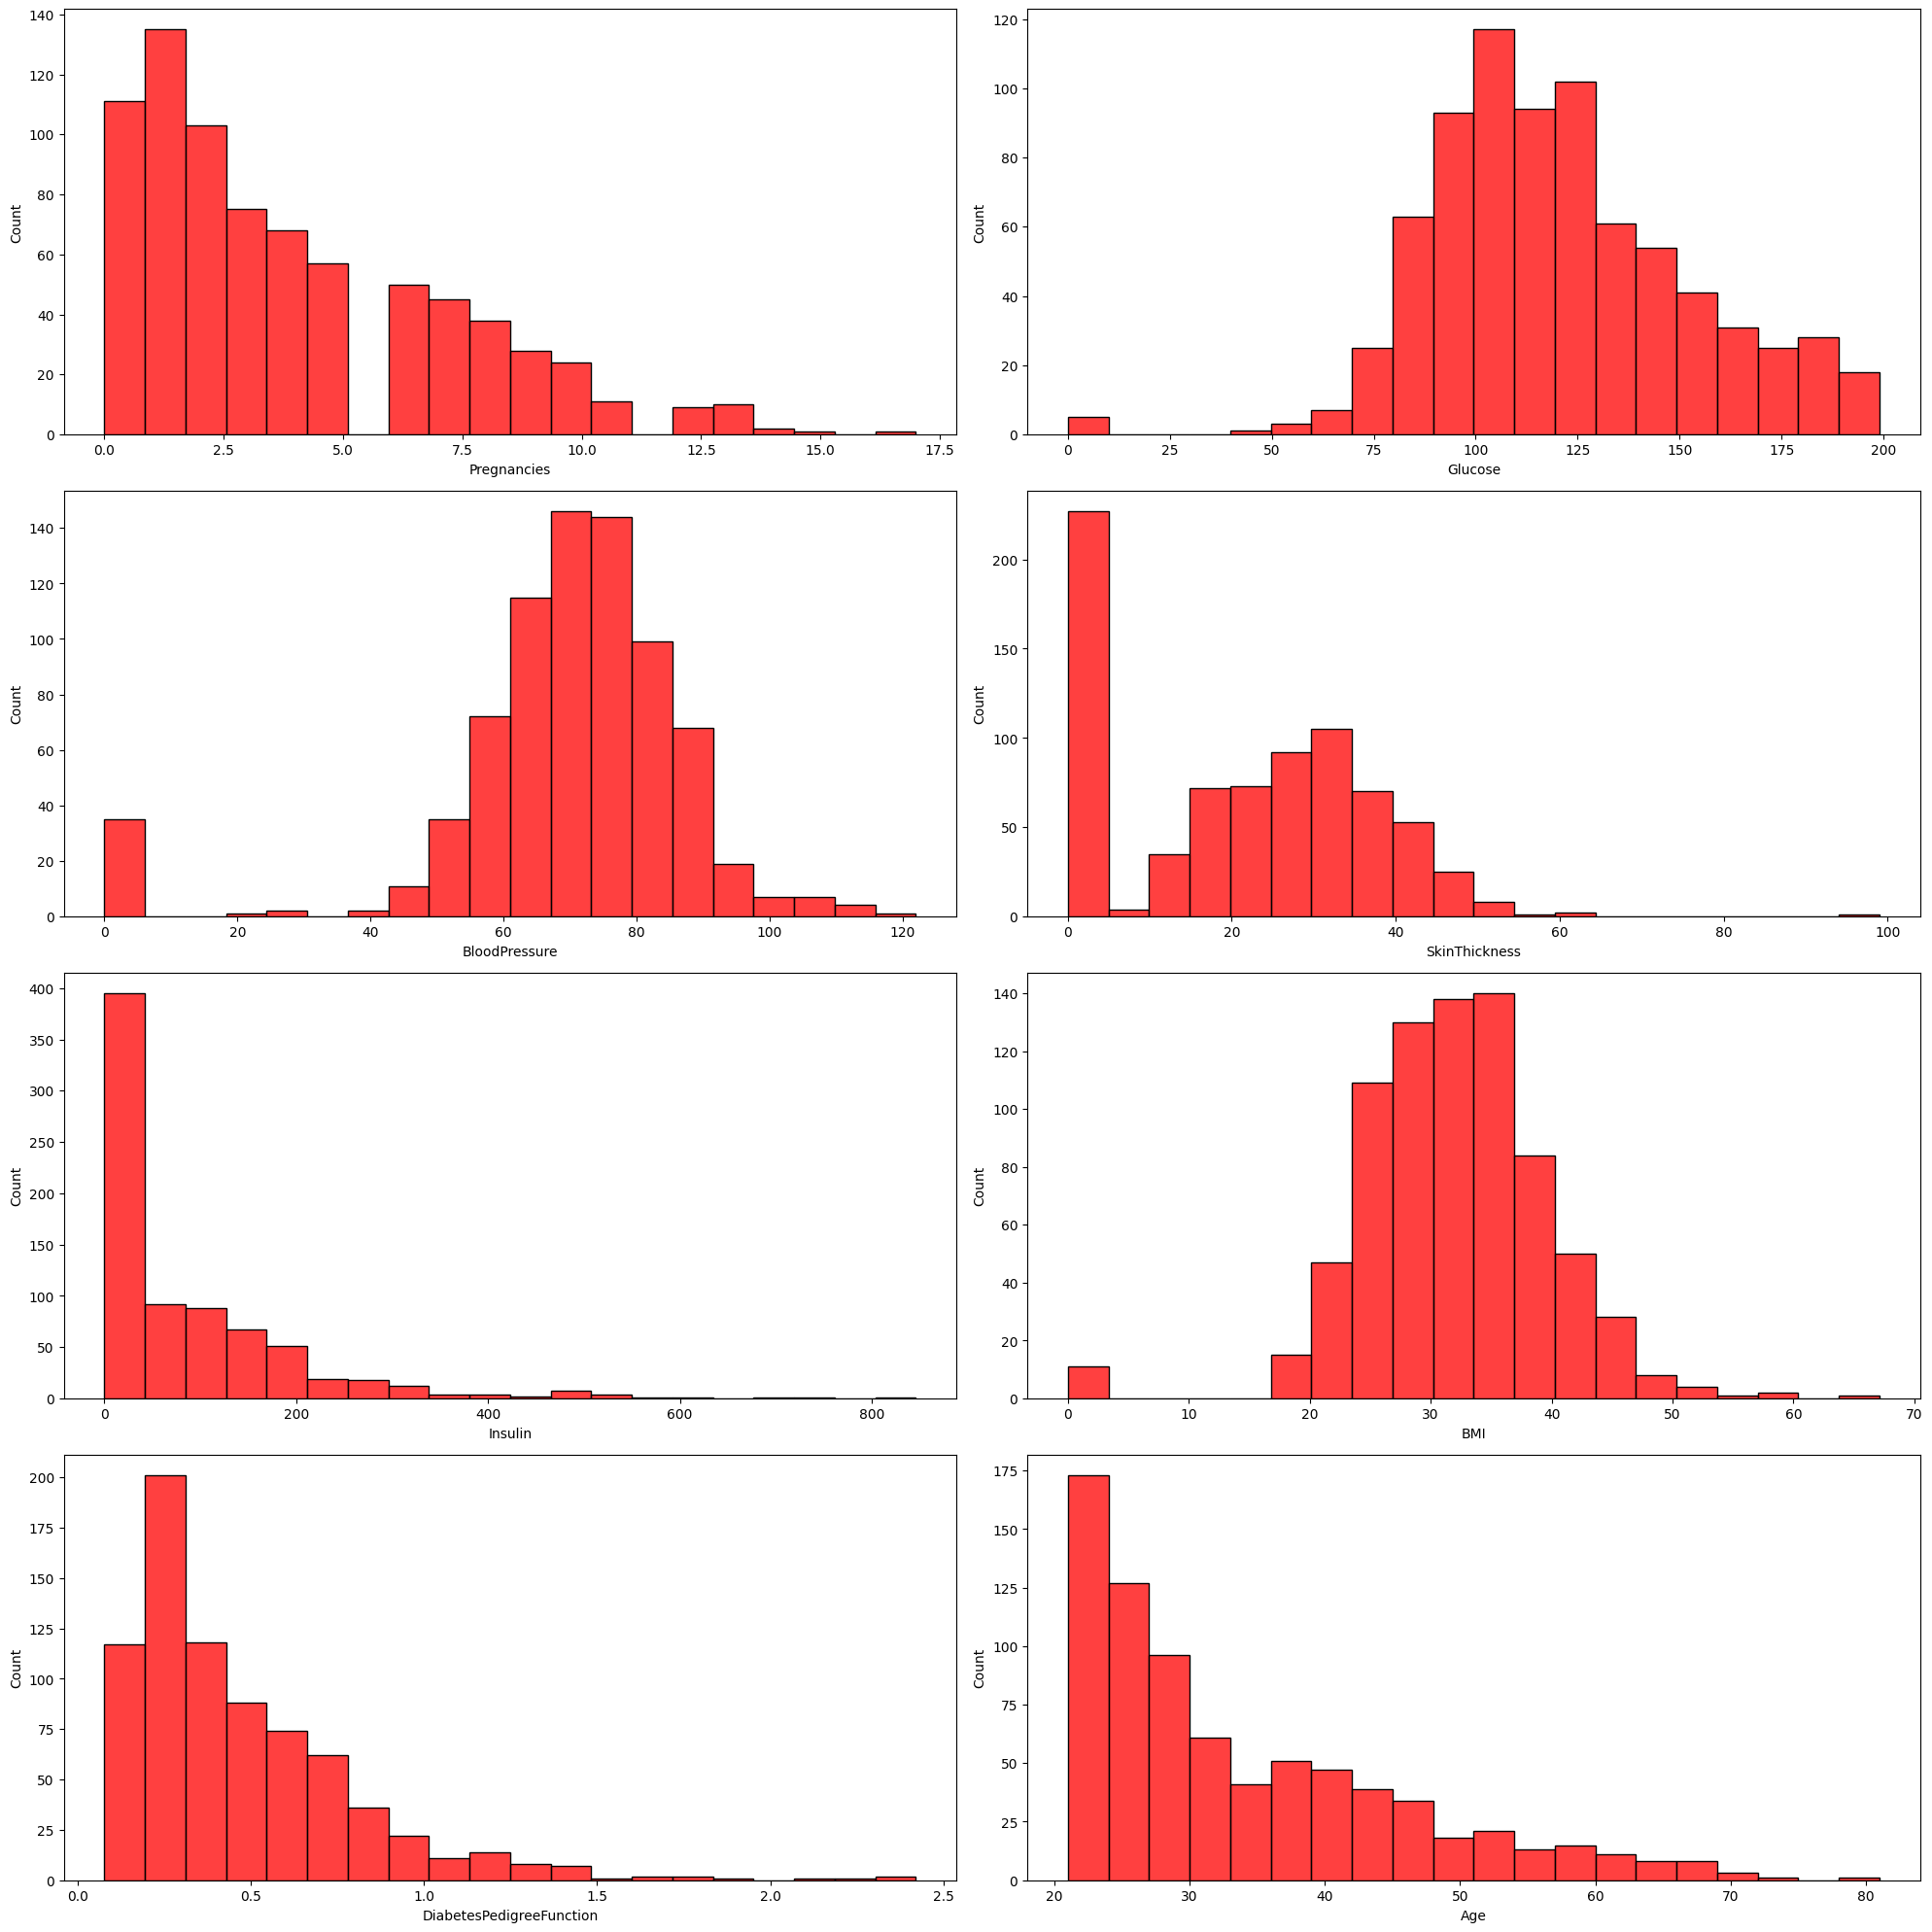

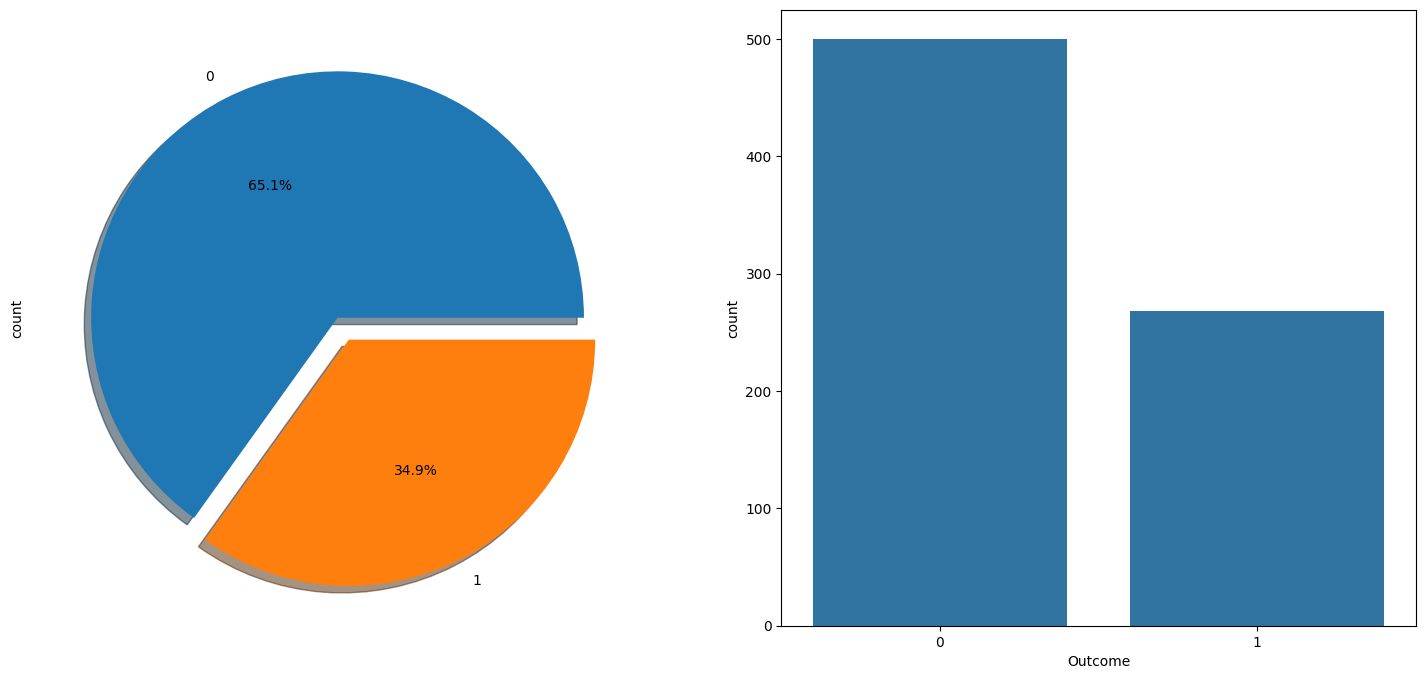

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [68]:
# Load dataset
df = pd.read_csv('/content/diabetes.csv')
df.head()

# Basic info and summary
print(df.info())
print(df.describe())
print(df.Outcome.value_counts(normalize=True) * 100)

# Visualize feature distributions
fig, ax = plt.subplots(4, 2, figsize=(20, 20))
for i, col in enumerate(df.columns[:-1]):
    sns.histplot(df[col], bins=20, ax=ax[i//2, i%2], color="red")
plt.tight_layout()
plt.show()

# Outcome distribution
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df['Outcome'].value_counts().plot.pie(explode=[0, 0.1], autopct="%1.1f%%", ax=ax[0], shadow=True)
sns.countplot(x='Outcome', data=df, ax=ax[1])
plt.show()

# Check for missing and zero values
print(df.isnull().sum())
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    print(f"{col}: {len(df[df[col] == 0])}")


In [69]:
# Replace invalid zeros with NaN
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Impute missing values with median by Outcome
def median_target(var):
    temp = df[df[var].notnull()]
    return temp.groupby('Outcome')[var].median()

for col in zero_cols:
    medians = median_target(col)
    df.loc[(df['Outcome'] == 0) & (df[col].isnull()), col] = medians[0]
    df.loc[(df['Outcome'] == 1) & (df[col].isnull()), col] = medians[1]

# Outlier handling for Insulin (IQR method)
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
df.loc[df['Insulin'] > upper, 'Insulin'] = upper

# Feature engineering: BMI and Glucose categories
df['NewBMI'] = pd.cut(df['BMI'], bins=[0, 18.5, 24.9, 29.9, 34.9, 39.9, np.inf],
                      labels=["Underweight", "Normal", "Overweight", "Obesity 1", "Obesity 2", "Obesity 3"])
df['NewInsulinScore'] = df['Insulin'].apply(lambda x: "Normal" if 16 <= x <= 166 else "Abnormal")
df['NewGlucose'] = pd.cut(df['Glucose'], bins=[0, 70, 99, 126, np.inf],
                          labels=["Low", "Normal", "Overweight", "High"])

# One-hot encoding for new categorical features
df = pd.get_dummies(df, columns=['NewBMI', 'NewInsulinScore', 'NewGlucose'], drop_first=True)

# Prepare features and target
y = df['Outcome']
X = df.drop(['Outcome'], axis=1)

# Robust scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [70]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, is_ann=False):
    results = []
    for X, y_true, label in [(X_train, y_train, "Training"), (X_test, y_test, "Validation")]:
        if is_ann:
            y_pred = (model.predict(X) > 0.5).astype("int32").flatten()
            y_proba = model.predict(X).flatten()
        else:
            y_pred = model.predict(X)
            y_proba = model.predict_proba(X)[:, 1]
        report = classification_report(y_true, y_pred, output_dict=True, digits=4)
        print(f"\n📊 Classification Report - {model_name} ({label})")
        print(classification_report(y_true, y_pred, digits=4))
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
        plt.title(f'Confusion Matrix - {model_name} ({label})')
        plt.show()
        results.append({
            'Model': model_name,
            'Dataset': label,
            'Accuracy': report['accuracy'],
            'Precision': report['1']['precision'],
            'Recall': report['1']['recall'],
            'F1-Score': report['1']['f1-score'],
            'AUC-ROC': roc_auc_score(y_true, y_proba)
        })
    return pd.DataFrame(results)



📊 Classification Report - Decision Tree (Training)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       393
           1     1.0000    1.0000    1.0000       221

    accuracy                         1.0000       614
   macro avg     1.0000    1.0000    1.0000       614
weighted avg     1.0000    1.0000    1.0000       614



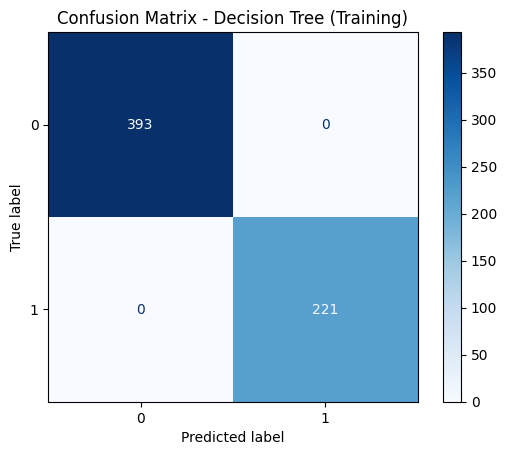


📊 Classification Report - Decision Tree (Validation)
              precision    recall  f1-score   support

           0     0.9029    0.8692    0.8857       107
           1     0.7255    0.7872    0.7551        47

    accuracy                         0.8442       154
   macro avg     0.8142    0.8282    0.8204       154
weighted avg     0.8488    0.8442    0.8459       154



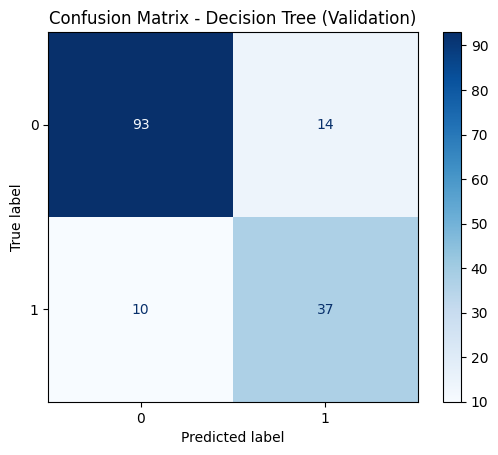


📊 Classification Report - SVM (Training)
              precision    recall  f1-score   support

           0     0.9150    0.9313    0.9231       393
           1     0.8738    0.8462    0.8598       221

    accuracy                         0.9007       614
   macro avg     0.8944    0.8887    0.8914       614
weighted avg     0.9002    0.9007    0.9003       614



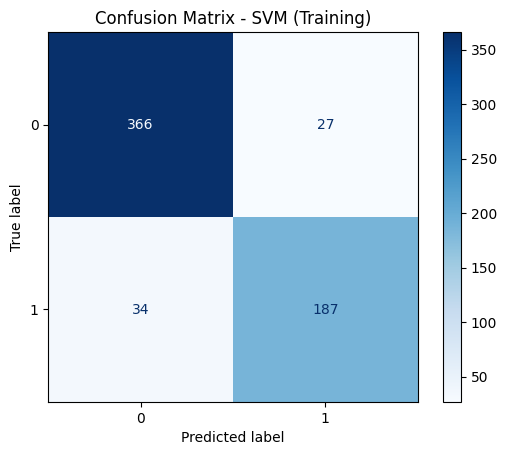


📊 Classification Report - SVM (Validation)
              precision    recall  f1-score   support

           0     0.9515    0.9159    0.9333       107
           1     0.8235    0.8936    0.8571        47

    accuracy                         0.9091       154
   macro avg     0.8875    0.9048    0.8952       154
weighted avg     0.9124    0.9091    0.9101       154



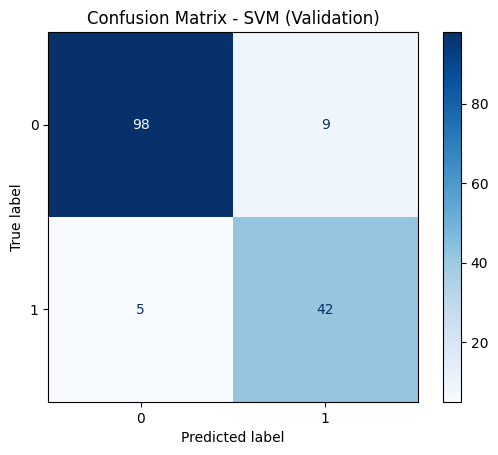

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📊 Classification Report - ANN (Training)
              precision    recall  f1-score   support

           0     0.8632    0.8830    0.8730       393
           1     0.7830    0.7511    0.7667       221

    accuracy                         0.8355       614
   macro avg     0.8231    0.8170    0.8198       614
weighted avg     0.8343    0.8355    0.8347       614



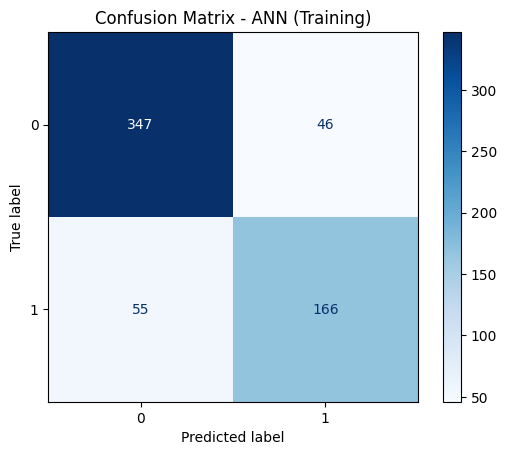

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

📊 Classification Report - ANN (Validation)
              precision    recall  f1-score   support

           0     0.9490    0.8692    0.9073       107
           1     0.7500    0.8936    0.8155        47

    accuracy                         0.8766       154
   macro avg     0.8495    0.8814    0.8614       154
weighted avg     0.8883    0.8766    0.8793       154



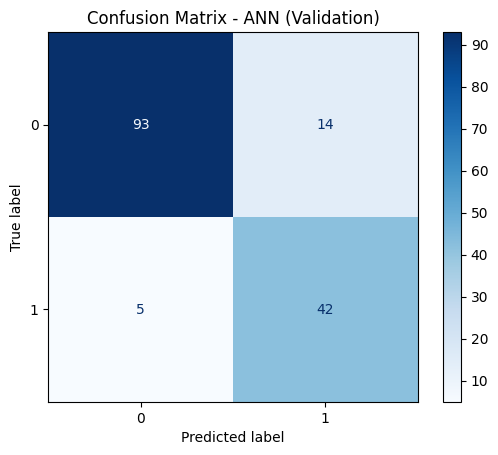

           Model     Dataset  Accuracy  Precision    Recall  F1-Score  \
0  Decision Tree    Training  1.000000   1.000000  1.000000  1.000000   
1  Decision Tree  Validation  0.844156   0.725490  0.787234  0.755102   
2            SVM    Training  0.900651   0.873832  0.846154  0.859770   
3            SVM  Validation  0.909091   0.823529  0.893617  0.857143   
4            ANN    Training  0.835505   0.783019  0.751131  0.766744   
5            ANN  Validation  0.876623   0.750000  0.893617  0.815534   

    AUC-ROC  
0  1.000000  
1  0.828196  
2  0.948039  
3  0.946311  
4  0.892623  
5  0.929807  


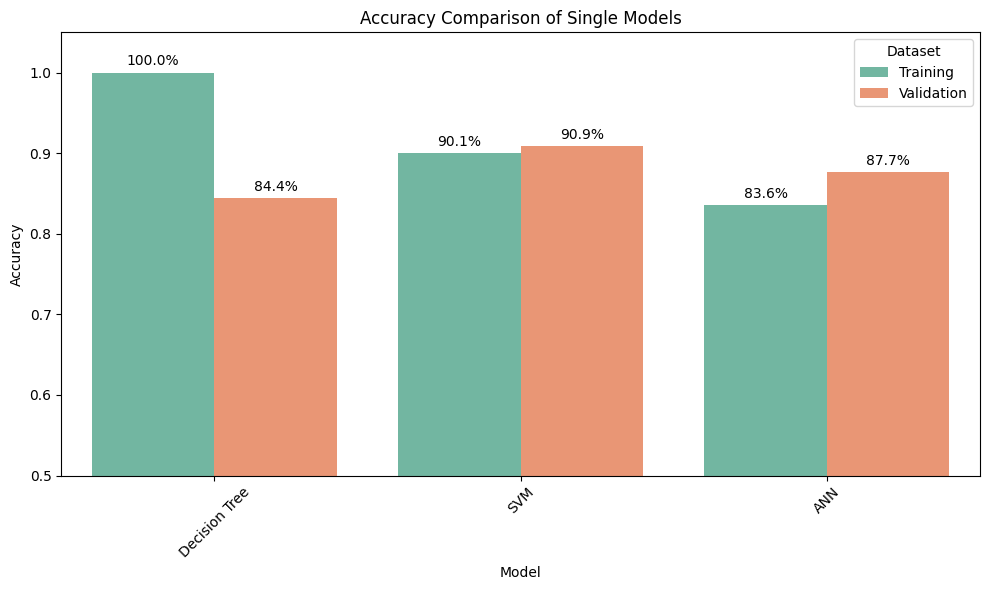

In [71]:
# Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
dt_results = evaluate_model(dtree, "Decision Tree", X_train, X_test, y_train, y_test)

# SVM
svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
svm_results = evaluate_model(svm, "SVM", X_train, X_test, y_train, y_test)

# ANN
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ann.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)
ann_results = evaluate_model(ann, "ANN", X_train, X_test, y_train, y_test, is_ann=True)

# Combine and display results
single_model_results = pd.concat([dt_results, svm_results, ann_results], ignore_index=True)
print(single_model_results)

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=single_model_results, x='Model', y='Accuracy', hue='Dataset', palette='Set2')
plt.ylim(0.5, 1.05)
plt.title('Accuracy Comparison of Single Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, labels=[f'{h.get_height()*100:.1f}%' for h in container])
plt.tight_layout()
plt.show()

In [72]:
# Define clinical threshold-based membership functions
glucose_range = np.arange(0, 200, 1)
bmi_range = np.arange(0, 50, 0.1)
insulin_range = np.arange(0, 850, 1)
dpf_range = np.arange(0, 2.5, 0.01)
age_range = np.arange(21, 90, 1)

# Function to generate fuzzy features from array data
def generate_fuzzy_features(X, glucose_mfs, bmi_mfs, insulin_mfs=None, age_mfs=None, dpf_mfs=None):
    # Convert DataFrame to array if needed
    if isinstance(X, pd.DataFrame):
        X_array = X.values
    else:
        X_array = X

    # Count total number of membership functions
    n_mfs = len(glucose_mfs) + len(bmi_mfs)
    if insulin_mfs is not None:
        n_mfs += len(insulin_mfs)
    if age_mfs is not None:
        n_mfs += len(age_mfs)
    if dpf_mfs is not None:
        n_mfs += len(dpf_mfs)

    # Initialize fuzzy features array
    n_samples = X_array.shape[0]
    fuzzy_features = np.zeros((n_samples, n_mfs))

    # Get feature indices - adjust based on your preprocessed dataset
    glucose_col = 1  # Index of Glucose in X
    bmi_col = 5      # Index of BMI in X
    insulin_col = 4  # Index of Insulin in X
    age_col = 7      # Index of Age in X
    dpf_col = 6      # Index of DiabetesPedigreeFunction in X

    # Calculate membership degrees for each sample
    for i in range(n_samples):
        # Glucose memberships
        idx = 0
        for j, mf in enumerate(glucose_mfs):
            fuzzy_features[i, idx] = fuzz.interp_membership(
                glucose_range, mf, X_array[i, glucose_col])
            idx += 1

        # BMI memberships
        for j, mf in enumerate(bmi_mfs):
            fuzzy_features[i, idx] = fuzz.interp_membership(
                bmi_range, mf, X_array[i, bmi_col])
            idx += 1

        # Insulin memberships (if provided)
        if insulin_mfs is not None:
            for j, mf in enumerate(insulin_mfs):
                fuzzy_features[i, idx] = fuzz.interp_membership(
                    insulin_range, mf, X_array[i, insulin_col])
                idx += 1

        # Age memberships (if provided)
        if age_mfs is not None:
            for j, mf in enumerate(age_mfs):
                fuzzy_features[i, idx] = fuzz.interp_membership(
                    age_range, mf, X_array[i, age_col])
                idx += 1

        # DPF memberships (if provided)
        if dpf_mfs is not None:
            for j, mf in enumerate(dpf_mfs):
                fuzzy_features[i, idx] = fuzz.interp_membership(
                    dpf_range, mf, X_array[i, dpf_col])
                idx += 1

    return fuzzy_features

# Create a lightweight model for surrogate training
def create_lightweight_nn(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Train surrogate model to predict performance based on membership function parameters
def train_surrogate_model(X_train, y_train, num_samples=40):
    """Build a surrogate model that predicts model performance from fuzzy parameters"""
    # Generate diverse parameter samples
    np.random.seed(42)
    fuzzy_params = []

    for _ in range(num_samples):
        params = [
            np.random.uniform(60, 80),   # glucose_low_center
            np.random.uniform(90, 110),  # glucose_normal_center
            np.random.uniform(120, 150), # glucose_high_center
            np.random.uniform(16, 18),   # bmi_under_center
            np.random.uniform(20, 24),   # bmi_normal_center
            np.random.uniform(26, 30),   # bmi_over_center
            np.random.uniform(32, 38)    # bmi_obese_center
        ]
        fuzzy_params.append(params)

    # Evaluate sample performance with actual models
    performances = []
    print(f"Evaluating {num_samples} parameter configurations for surrogate model...")

    for i, params in enumerate(fuzzy_params):
        if i % 5 == 0:
            print(f"  Progress: {i}/{num_samples} configurations")

        # Create membership functions with these parameters
        glucose_low = fuzz.trimf(glucose_range, [0, params[0], params[1]])
        glucose_normal = fuzz.trimf(glucose_range, [params[0], params[1], params[2]])
        glucose_high = fuzz.trimf(glucose_range, [params[1], params[2], 200])

        bmi_under = fuzz.trimf(bmi_range, [0, params[3], params[4]])
        bmi_normal = fuzz.trimf(bmi_range, [params[3], params[4], params[5]])
        bmi_over = fuzz.trimf(bmi_range, [params[4], params[5], params[6]])
        bmi_obese = fuzz.trimf(bmi_range, [params[5], params[6], 50])

        # Generate fuzzy features with these membership functions
        fuzzy_features = generate_fuzzy_features(
            X_train,
            [glucose_low, glucose_normal, glucose_high],
            [bmi_under, bmi_normal, bmi_over, bmi_obese]
        )

        # Train a lightweight model to estimate performance
        X_combined = np.hstack([X_train, fuzzy_features])
        model = create_lightweight_nn(X_combined.shape[1])
        history = model.fit(
            X_combined, y_train,
            validation_split=0.2,
            epochs=20, batch_size=32, verbose=0
        )

        # Use validation accuracy as performance metric
        performances.append(np.max(history.history['val_accuracy']))

    # Train surrogate model to predict performance from parameters
    surrogate = RandomForestRegressor(n_estimators=100, random_state=42)
    surrogate.fit(np.array(fuzzy_params), np.array(performances))

    # Validate surrogate model
    plt.figure(figsize=(8, 5))
    plt.scatter(performances, surrogate.predict(fuzzy_params))
    plt.plot([min(performances), max(performances)], [min(performances), max(performances)], 'r--')
    plt.xlabel("Actual Model Performance")
    plt.ylabel("Surrogate Predicted Performance")
    plt.title("Surrogate Model Prediction Quality")
    plt.tight_layout()
    plt.show()

    return surrogate, fuzzy_params, performances

# Create objective function using surrogate model
def create_surrogate_objective(surrogate_model):
    """Create a fast objective function using surrogate predictions"""
    def objective_function(params):
        # Predict performance using surrogate instead of training full NN
        params_reshaped = np.array(params).reshape(1, -1)
        predicted_performance = surrogate_model.predict(params_reshaped)[0]
        return -predicted_performance  # Negative because optimizer minimizes

    return objective_function

# Optimize membership functions using Harris Hawks Optimization with surrogate
class SurrogateHHO:
    def __init__(self, objective_function, dim, search_agents_no=20, max_iter=50, lb=None, ub=None):
        self.objective_function = objective_function
        self.dim = dim
        self.search_agents_no = search_agents_no
        self.max_iter = max_iter
        self.lb = np.array([lb] * dim) if np.isscalar(lb) else np.array(lb)
        self.ub = np.array([ub] * dim) if np.isscalar(ub) else np.array(ub)

    def optimize(self):
        # Initialize population
        X = np.random.uniform(self.lb, self.ub, (self.search_agents_no, self.dim))

        # Initialize fitness
        fitness = np.zeros(self.search_agents_no)
        for i in range(self.search_agents_no):
            fitness[i] = self.objective_function(X[i])

        # Initialize best solution
        idx = np.argmin(fitness)
        rabbit_location = X[idx].copy()
        rabbit_energy = fitness[idx]

        # Store convergence history
        convergence_curve = np.zeros(self.max_iter)

        # Main optimization loop
        for t in range(self.max_iter):
            # Update E1 parameter (decreases linearly from 2 to 0)
            E1 = 2 * (1 - (t / self.max_iter))

            # Update each hawk's position
            for i in range(self.search_agents_no):
                # Phase selection parameter
                q = np.random.rand()

                if q >= 0.5:  # Exploration phase
                    if abs(E1) >= 1:
                        # Select random hawk
                        random_idx = np.random.randint(0, self.search_agents_no)
                        X_rand = X[random_idx]
                        X[i] = X_rand - np.random.rand() * np.abs(X_rand - 2*np.random.rand()*X[i])
                    else:
                        # Soft besiege
                        X[i] = (rabbit_location - X.mean(axis=0)) - np.random.rand() * \
                                ((self.ub - self.lb) * np.random.rand() + self.lb)

                else:  # Exploitation phase
                    r = np.random.rand()
                    if r >= 0.5 and abs(E1) >= 0.5:  # Hard besiege
                        X[i] = rabbit_location - E1 * np.abs(rabbit_location - X[i])
                    elif r >= 0.5 and abs(E1) < 0.5:  # Hard besiege with progressive rapid dives
                        Y = rabbit_location - E1 * np.abs(rabbit_location - X[i])
                        Z = Y + np.random.randn(self.dim) * np.mean(np.abs(Y))

                        # Evaluate Y and Z
                        Y_fitness = self.objective_function(Y)
                        Z_fitness = self.objective_function(Z)

                        # Update position based on best fitness
                        if Y_fitness < fitness[i]:
                            X[i] = Y
                            fitness[i] = Y_fitness
                        elif Z_fitness < fitness[i]:
                            X[i] = Z
                            fitness[i] = Z_fitness

                    elif r < 0.5 and abs(E1) >= 0.5:  # Soft besiege
                        J = 2 * (1 - np.random.rand())
                        X[i] = rabbit_location - E1 * np.abs(J * rabbit_location - X[i])

                    elif r < 0.5 and abs(E1) < 0.5:  # Soft besiege with progressive rapid dives
                        J = 2 * (1 - np.random.rand())
                        Y = rabbit_location - E1 * np.abs(J * rabbit_location - X[i])
                        Z = Y + np.random.randn(self.dim) * np.mean(np.abs(Y))

                        # Evaluate Y and Z
                        Y_fitness = self.objective_function(Y)
                        Z_fitness = self.objective_function(Z)

                        # Update position based on best fitness
                        if Y_fitness < fitness[i]:
                            X[i] = Y
                            fitness[i] = Y_fitness
                        elif Z_fitness < fitness[i]:
                            X[i] = Z
                            fitness[i] = Z_fitness

                # Boundary check
                X[i] = np.clip(X[i], self.lb, self.ub)

                # Update fitness
                fitness[i] = self.objective_function(X[i])

                # Update rabbit if better solution found
                if fitness[i] < rabbit_energy:
                    rabbit_energy = fitness[i]
                    rabbit_location = X[i].copy()

            # Store best fitness
            convergence_curve[t] = rabbit_energy

            # Display optimization progress
            if t % 10 == 0 or t == self.max_iter-1:
                print(f"Iteration {t}: Best fitness = {rabbit_energy:.6f}")

        return rabbit_location, rabbit_energy, convergence_curve


# Complete Fuzzy+ANN Hybrid Model Implementation

Step 1: Training surrogate model...
Evaluating 40 parameter configurations for surrogate model...
  Progress: 0/40 configurations
  Progress: 5/40 configurations
  Progress: 10/40 configurations
  Progress: 15/40 configurations
  Progress: 20/40 configurations
  Progress: 25/40 configurations
  Progress: 30/40 configurations
  Progress: 35/40 configurations


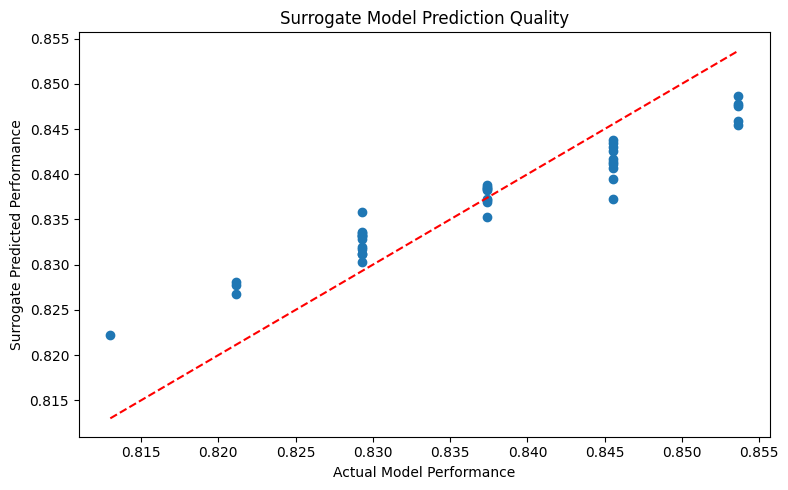

Step 2: Creating surrogate objective function...
Step 3: Running optimization with surrogate model...
Iteration 0: Best fitness = -0.840650
Iteration 10: Best fitness = -0.840732
Iteration 20: Best fitness = -0.840732
Iteration 29: Best fitness = -0.840732
Step 4: Validating optimal solution with full model...

Optimized model validation results:
Accuracy: 0.8831
Precision: 0.7544
Recall: 0.9149
AUC: 0.9594

Optimization Results:
Best parameters: [np.float64(67.16), np.float64(90.0), np.float64(146.06), np.float64(16.0), np.float64(20.0), np.float64(26.0), np.float64(32.0)]
Surrogate predicted accuracy: 0.8407
Actual validation accuracy: 0.8831


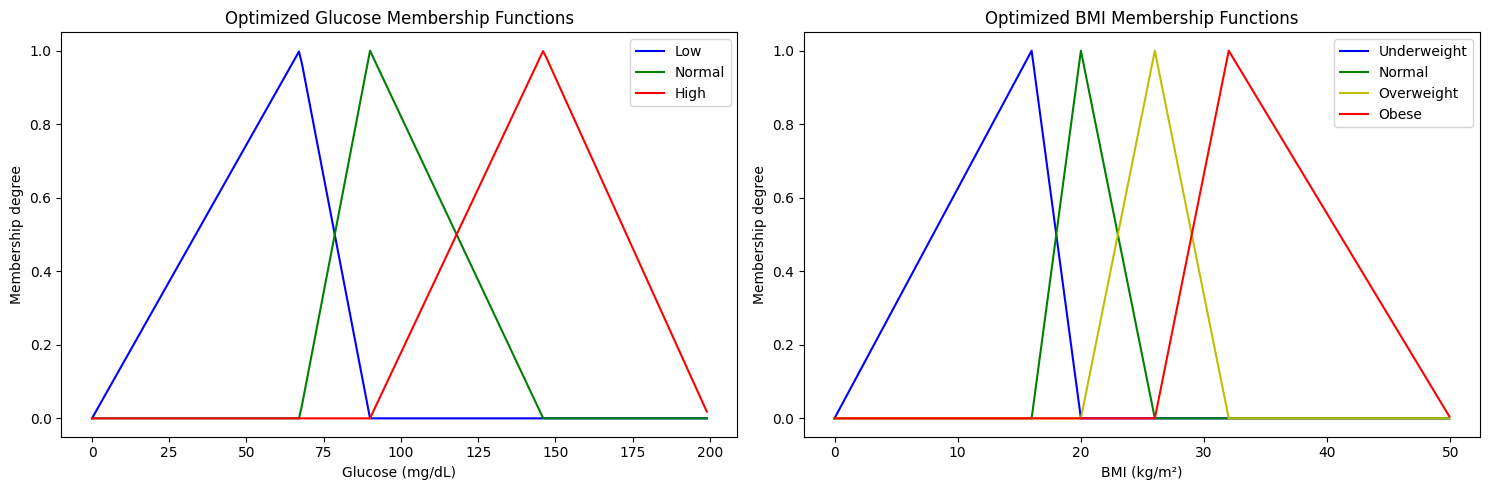

Total optimization time: 223.90 seconds
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📊 Classification Report - Fuzzy+ANN (Training)
              precision    recall  f1-score   support

           0     0.9405    0.8855    0.9122       393
           1     0.8156    0.9005    0.8559       221

    accuracy                         0.8909       614
   macro avg     0.8781    0.8930    0.8841       614
weighted avg     0.8956    0.8909    0.8919       614



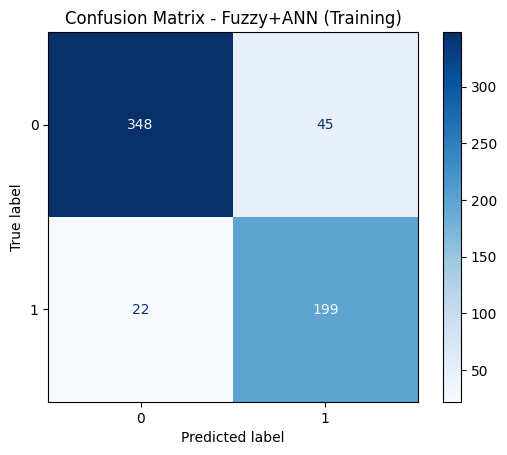

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 Classification Report - Fuzzy+ANN (Validation)
              precision    recall  f1-score   support

           0     0.9588    0.8692    0.9118       107
           1     0.7544    0.9149    0.8269        47

    accuracy                         0.8831       154
   macro avg     0.8566    0.8920    0.8693       154
weighted avg     0.8964    0.8831    0.8859       154



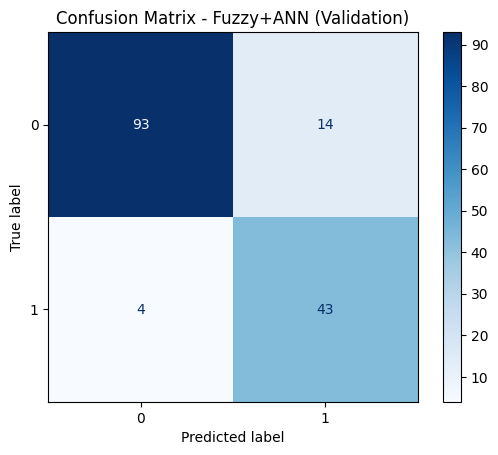

In [73]:
def validate_solution(params, X_train, y_train, X_test, y_test):
    """Validate a parameter set by training an actual neural network"""
    # Create membership functions with optimized parameters
    glucose_low = fuzz.trimf(glucose_range, [0, params[0], params[1]])
    glucose_normal = fuzz.trimf(glucose_range, [params[0], params[1], params[2]])
    glucose_high = fuzz.trimf(glucose_range, [params[1], params[2], 200])

    bmi_under = fuzz.trimf(bmi_range, [0, params[3], params[4]])
    bmi_normal = fuzz.trimf(bmi_range, [params[3], params[4], params[5]])
    bmi_over = fuzz.trimf(bmi_range, [params[4], params[5], params[6]])
    bmi_obese = fuzz.trimf(bmi_range, [params[5], params[6], 50])

    # Create insulin membership functions based on clinical thresholds
    insulin_low = fuzz.trimf(insulin_range, [0, 16, 166])
    insulin_normal = fuzz.trimf(insulin_range, [16, 166, 300])
    insulin_high = fuzz.trimf(insulin_range, [166, 300, 846])

    # Generate fuzzy features
    fuzzy_features_train = generate_fuzzy_features(
        X_train,
        [glucose_low, glucose_normal, glucose_high],
        [bmi_under, bmi_normal, bmi_over, bmi_obese],
        [insulin_low, insulin_normal, insulin_high]
    )

    fuzzy_features_test = generate_fuzzy_features(
        X_test,
        [glucose_low, glucose_normal, glucose_high],
        [bmi_under, bmi_normal, bmi_over, bmi_obese],
        [insulin_low, insulin_normal, insulin_high]
    )

    # Create combined features
    X_train_combined = np.hstack([X_train, fuzzy_features_train])
    X_test_combined = np.hstack([X_test, fuzzy_features_test])

    # Calculate class weights to handle imbalance
    n_neg, n_pos = np.bincount(y_train)
    class_weight = {0: 1.0, 1: n_neg/n_pos}

    # Build and train the full model with enhanced architecture
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_combined.shape[1],)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )

    # Train with validation data and class weights
    history = model.fit(
        X_train_combined, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        class_weight=class_weight,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
        verbose=0
    )

    # Evaluate on test data
    results = model.evaluate(X_test_combined, y_test, verbose=0)
    print(f"\nOptimized model validation results:")
    print(f"Accuracy: {results[1]:.4f}")
    print(f"Precision: {results[2]:.4f}")
    print(f"Recall: {results[3]:.4f}")
    print(f"AUC: {results[4]:.4f}")

    return model, X_train_combined, X_test_combined, results[1]

def optimize_with_surrogate():
    """Complete workflow for surrogate-based fuzzy membership function optimization"""
    # Parameter bounds for optimization
    lb = [60, 90, 120, 16, 20, 26, 32]   # Lower bounds based on clinical thresholds
    ub = [80, 110, 150, 18, 24, 30, 38]  # Upper bounds based on clinical thresholds

    # 1. Train surrogate model on sample evaluations
    print("Step 1: Training surrogate model...")
    surrogate_model, param_samples, performances = train_surrogate_model(
        X_train, y_train, num_samples=40  # Start with 40 samples
    )

    # 2. Create fast objective function using surrogate
    print("Step 2: Creating surrogate objective function...")
    objective_function = create_surrogate_objective(surrogate_model)

    # 3. Run HHO optimization using surrogate predictions
    print("Step 3: Running optimization with surrogate model...")
    hho = SurrogateHHO(objective_function, dim=7, search_agents_no=20, max_iter=30, lb=lb, ub=ub)
    best_params, best_fitness, convergence = hho.optimize()

    # 4. Validate final solution with actual model
    print("Step 4: Validating optimal solution with full model...")
    hybrid_ann, X_train_hybrid, X_test_hybrid, validation_accuracy = validate_solution(
        best_params, X_train, y_train, X_test, y_test
    )

    print("\nOptimization Results:")
    print(f"Best parameters: {[round(p, 2) for p in best_params]}")
    print(f"Surrogate predicted accuracy: {-best_fitness:.4f}")
    print(f"Actual validation accuracy: {validation_accuracy:.4f}")

    # 5. Plot the optimized membership functions
    plt.figure(figsize=(15, 5))

    # Glucose membership functions
    plt.subplot(1, 2, 1)
    glucose_low = fuzz.trimf(glucose_range, [0, best_params[0], best_params[1]])
    glucose_normal = fuzz.trimf(glucose_range, [best_params[0], best_params[1], best_params[2]])
    glucose_high = fuzz.trimf(glucose_range, [best_params[1], best_params[2], 200])

    plt.plot(glucose_range, glucose_low, 'b', linewidth=1.5, label='Low')
    plt.plot(glucose_range, glucose_normal, 'g', linewidth=1.5, label='Normal')
    plt.plot(glucose_range, glucose_high, 'r', linewidth=1.5, label='High')
    plt.title('Optimized Glucose Membership Functions')
    plt.ylabel('Membership degree')
    plt.xlabel('Glucose (mg/dL)')
    plt.legend()

    # BMI membership functions
    plt.subplot(1, 2, 2)
    bmi_under = fuzz.trimf(bmi_range, [0, best_params[3], best_params[4]])
    bmi_normal = fuzz.trimf(bmi_range, [best_params[3], best_params[4], best_params[5]])
    bmi_over = fuzz.trimf(bmi_range, [best_params[4], best_params[5], best_params[6]])
    bmi_obese = fuzz.trimf(bmi_range, [best_params[5], best_params[6], 50])

    plt.plot(bmi_range, bmi_under, 'b', linewidth=1.5, label='Underweight')
    plt.plot(bmi_range, bmi_normal, 'g', linewidth=1.5, label='Normal')
    plt.plot(bmi_range, bmi_over, 'y', linewidth=1.5, label='Overweight')
    plt.plot(bmi_range, bmi_obese, 'r', linewidth=1.5, label='Obese')
    plt.title('Optimized BMI Membership Functions')
    plt.ylabel('Membership degree')
    plt.xlabel('BMI (kg/m²)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return hybrid_ann, X_train_hybrid, X_test_hybrid

# Run the optimization
start_time = time.time()
hybrid_ann, X_train_hybrid, X_test_hybrid = optimize_with_surrogate()
print(f"Total optimization time: {time.time() - start_time:.2f} seconds")

# Evaluate the final optimized model
hybrid_results = evaluate_model(hybrid_ann, "Fuzzy+ANN", X_train_hybrid, X_test_hybrid, y_train, y_test, is_ann=True)



Final Results Summary:
           Model     Dataset  Accuracy  Precision    Recall  F1-Score  \
0  Decision Tree    Training  1.000000   1.000000  1.000000  1.000000   
1  Decision Tree  Validation  0.844156   0.725490  0.787234  0.755102   
2            SVM    Training  0.900651   0.873832  0.846154  0.859770   
3            SVM  Validation  0.909091   0.823529  0.893617  0.857143   
4            ANN    Training  0.835505   0.783019  0.751131  0.766744   
5            ANN  Validation  0.876623   0.750000  0.893617  0.815534   
6      Fuzzy+ANN    Training  0.890879   0.815574  0.900452  0.855914   
7      Fuzzy+ANN  Validation  0.883117   0.754386  0.914894  0.826923   

    AUC-ROC  
0  1.000000  
1  0.828196  
2  0.948039  
3  0.946311  
4  0.892623  
5  0.929807  
6  0.938459  
7  0.959236  


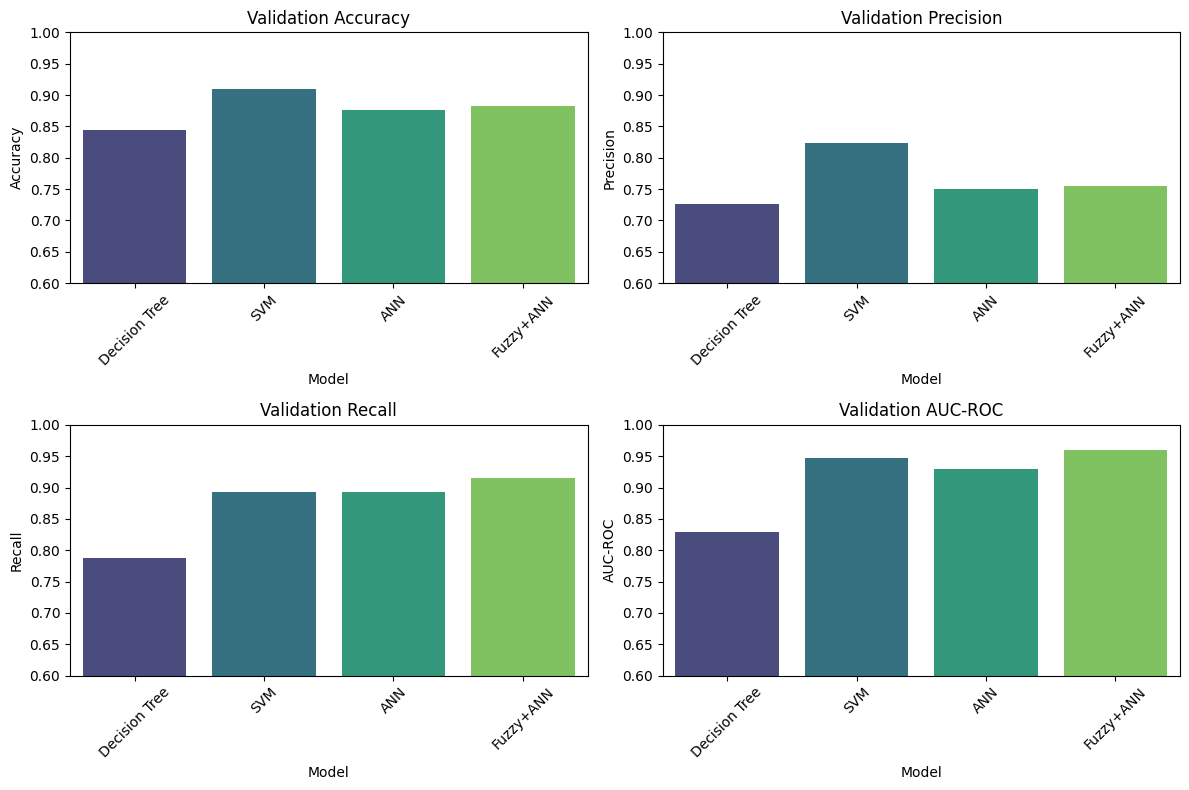

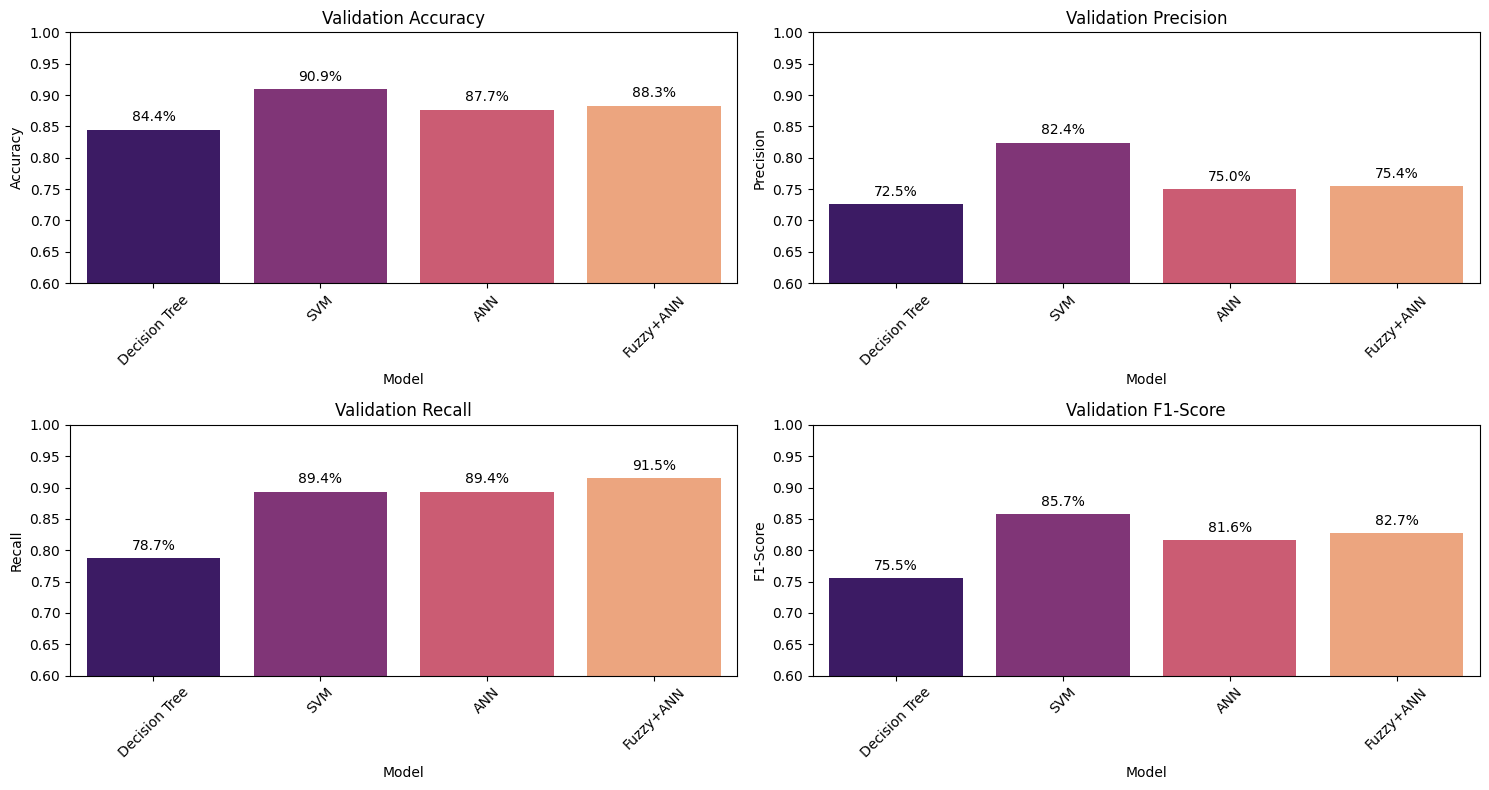

In [74]:
# Combine results from all models
final_results = pd.concat([single_model_results, hybrid_results], ignore_index=True)

# Display final results
print("\nFinal Results Summary:")
print(final_results)

# Create comparison visualization
plt.figure(figsize=(12, 8))

# Plot accuracy comparison
plt.subplot(2, 2, 1)
sns.barplot(data=final_results[final_results['Dataset'] == 'Validation'],
            x='Model', y='Accuracy', palette='viridis')
plt.title('Validation Accuracy')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.0)

# Plot precision comparison
plt.subplot(2, 2, 2)
sns.barplot(data=final_results[final_results['Dataset'] == 'Validation'],
            x='Model', y='Precision', palette='viridis')
plt.title('Validation Precision')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.0)

# Plot recall comparison
plt.subplot(2, 2, 3)
sns.barplot(data=final_results[final_results['Dataset'] == 'Validation'],
            x='Model', y='Recall', palette='viridis')
plt.title('Validation Recall')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.0)

# Plot AUC-ROC comparison
plt.subplot(2, 2, 4)
sns.barplot(data=final_results[final_results['Dataset'] == 'Validation'],
            x='Model', y='AUC-ROC', palette='viridis')
plt.title('Validation AUC-ROC')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.0)

plt.tight_layout()
plt.show()

# Create a combined bar chart with all models and metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
val_results = final_results[final_results['Dataset'] == 'Validation']

plt.figure(figsize=(15, 8))
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    ax = sns.barplot(data=val_results, x='Model', y=metric, palette='magma')
    plt.title(f'Validation {metric}')
    plt.xticks(rotation=45)
    plt.ylim(0.6, 1.0)

    # Add percentage labels
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

plt.tight_layout()
plt.show()
